# H0 Fold-aligned Prediction Stability Audit

## Goal

동일 outer fold에서 validation 행을 제외한 seed 42/777/2024 H0 확률만 이용해, 3-seed bagging의 안정성·오류 회복을 점검합니다. 새 모델·피처·threshold·blend를 만들지 않습니다.

### Dacon / 팀 계약

- 입력은 기존 train-only, fold-aligned OOF 확률 CSV입니다.
- `test.csv`를 읽지 않고 모델 fitting도 하지 않습니다.
- cross-split OOF 평균을 사용하지 않습니다.
- 결과는 후속 일반화 실험의 근거이며 제출 파일을 만들지 않습니다.

In [4]:
from pathlib import Path
import subprocess, sys
from tqdm.auto import tqdm

ROOT = Path('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton')
BASE = ROOT / 'experiments' / 'gs' / 'notebooks' / 'exp_model_014'
RUNNER = BASE / 'common' / 'run_h0_prediction_stability_audit.py'
RESULT = BASE / 'result'
INPUT = ROOT / 'experiments' / 'gs' / 'notebooks' / 'exp_model_010' / 'result' / 'exp-fold-aligned-h0-bagging-audit-01_oof_probabilities.csv'
RUN_ID = 'exp-h0-prediction-stability-audit-01'
RUN_EXPERIMENT = True
assert RUNNER.exists() and INPUT.exists(), (RUNNER, INPUT)
print({'runner': RUNNER, 'input': INPUT, 'test_read': False, 'models_refit': False})

{'runner': PosixPath('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/experiments/gs/notebooks/exp_model_014/common/run_h0_prediction_stability_audit.py'), 'input': PosixPath('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/experiments/gs/notebooks/exp_model_010/result/exp-fold-aligned-h0-bagging-audit-01_oof_probabilities.csv'), 'test_read': False, 'models_refit': False}


In [5]:
if RUN_EXPERIMENT:
    command = [sys.executable, str(RUNNER), '--input', str(INPUT), '--run-id', RUN_ID]
    process = subprocess.Popen(command, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
    tail = []
    for line in tqdm(process.stdout, desc='prediction stability audit', unit='line'):
        print(line, end='')
        tail = (tail + [line])[-80:]
    if process.wait():
        raise RuntimeError('audit failed:\n' + ''.join(tail))
else:
    print('RUN_EXPERIMENT=False: existing result files only.')

prediction stability audit: 1line [00:02,  2.75s/line]

{
  "purpose": "h0_fold_aligned_prediction_stability_audit",
  "input_role": "precomputed_train_only_fold_aligned_oof",
  "test_read": false,
  "train_test_concat": false,
  "models_refit": false,
  "invalid_cross_split_oof_average_used": false,
  "seeds": [
    42,
    777,
    2024
  ],
  "row_count": 6201,
  "class_count": 26,
  "recovered_seed42_errors": 114,
  "broken_seed42_correct": 111,
  "all_seed_agree_rate": 0.8009998387356878,
  "leakage_check": true,
  "nan_as_mutation_count": 0
}


prediction stability audit: 20line [00:02,  6.68line/s]


,variant,oof_macro_f1,oof_accuracy,delta_vs_seed42
0,seed_42,0.547915,0.558942,0.000000
3,fold_aligned_bagged,0.546091,0.559426,-0.001823
2,seed_2024,0.543552,0.556201,-0.004363
1,seed_777,0.542721,0.557652,-0.005194


,transition,rows
0,both_correct,3355
1,both_wrong,2621
2,recovered,114
3,broken,111


,stability,rows
0,all_agree,4967
1,two_agree,1106
2,all_different,128


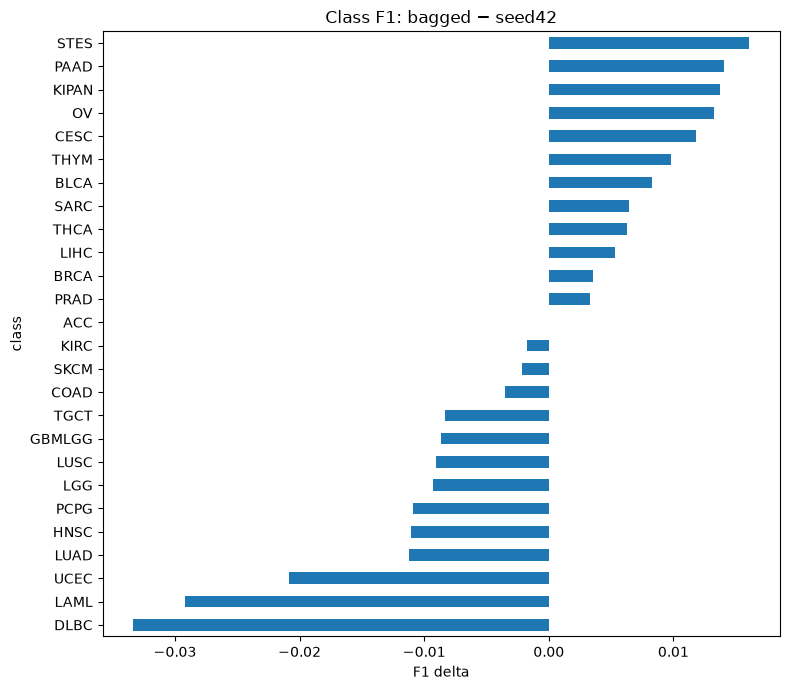

{'decision': 'bagging OOF does not exceed seed42; retain it only as an LB-generalization candidate', 'purpose': 'h0_fold_aligned_prediction_stability_audit', 'input_role': 'precomputed_train_only_fold_aligned_oof', 'test_read': False, 'train_test_concat': False, 'models_refit': False, 'invalid_cross_split_oof_average_used': False, 'seeds': [42, 777, 2024], 'row_count': 6201, 'class_count': 26, 'recovered_seed42_errors': 114, 'broken_seed42_correct': 111, 'all_seed_agree_rate': 0.8009998387356878, 'leakage_check': True, 'nan_as_mutation_count': 0}


In [6]:
import json
import matplotlib.pyplot as plt
import pandas as pd

summary = pd.read_csv(RESULT / f'{RUN_ID}_summary.csv')
rows = pd.read_csv(RESULT / f'{RUN_ID}_row_audit.csv')
classes = pd.read_csv(RESULT / f'{RUN_ID}_class_metrics.csv')
audit = json.loads((RESULT / f'{RUN_ID}_leakage_audit.json').read_text())
assert audit['leakage_check'] and audit['nan_as_mutation_count'] == 0
assert not audit['test_read'] and not audit['models_refit']
display(summary.sort_values('oof_macro_f1', ascending=False))
display(rows.bagging_transition.value_counts().rename_axis('transition').reset_index(name='rows'))
display(rows.seed_prediction_stability.value_counts().rename_axis('stability').reset_index(name='rows'))

class_f1 = classes.pivot(index='class', columns='variant', values='f1')
(class_f1['fold_aligned_bagged'] - class_f1['seed_42']).sort_values().plot.barh(figsize=(8, 7), title='Class F1: bagged − seed42')
plt.xlabel('F1 delta'); plt.tight_layout(); plt.show()

decision = 'bagging keeps or improves the valid seed42 OOF' if float(summary.loc[summary.variant.eq('fold_aligned_bagged'), 'delta_vs_seed42'].iloc[0]) >= 0 else 'bagging OOF does not exceed seed42; retain it only as an LB-generalization candidate'
print({'decision': decision, **audit})